# 🚀 Streamlined Urdu to Roman Urdu Translation

This notebook contains a streamlined implementation with:
- ⚡ BPE tokenization for better subword handling
- 🎯 Attention mechanism with bidirectional encoder
- 🔧 Optimized training with reduced data load
- 📊 BLEU score evaluation
- 🚀 Clean, efficient code

## Key Features:
- **BPE Tokenization**: Subword-level tokenization
- **Bidirectional Encoder**: Better input representation
- **BLEU Evaluation**: Standard NMT evaluation metric
- **Reduced Training**: Half the data load for efficiency
- **Clean Implementation**: Streamlined codebase

In [ ]:
# Essential imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
from collections import Counter
import math

# Check CUDA availability
print("🚀 PyTorch CUDA Information:")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available - using CPU")
print("-" * 50)

🚀 PyTorch CUDA Information:
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Number of GPUs: 1
Current GPU: 0
GPU Name: NVIDIA GeForce GTX 750 Ti
--------------------------------------------------


In [18]:
# Data Loading and BPE Implementation
def load_translation_pairs(file_path):
    """Load Urdu-Roman Urdu translation pairs from the dataset."""
    pairs = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if '\t' in line:
                urdu, roman_urdu = line.split('\t', 1)
                pairs.append((urdu.strip(), roman_urdu.strip()))
    return pairs

def simple_bpe(text, vocab_size=1000):
    """Simple BPE implementation for tokenization."""
    words = text.split()
    vocab = set()
    
    # Start with character-level vocabulary
    for word in words:
        vocab.update(list(word))
    
    word_tokens = [list(word) for word in words]
    
    def get_pairs(word_tokens):
        pairs = Counter()
        for word in word_tokens:
            for i in range(len(word) - 1):
                pairs[(word[i], word[i+1])] += 1
        return pairs
    
    def merge_vocab(pair, word_tokens):
        new_word_tokens = []
        for word in word_tokens:
            new_word = []
            i = 0
            while i < len(word):
                if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                    new_word.append(''.join(pair))
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_word_tokens.append(new_word)
        return new_word_tokens
    
    # BPE iterations
    iteration = 0
    while len(vocab) < vocab_size:
        pairs = get_pairs(word_tokens)
        if not pairs:
            break
            
        most_frequent_pair = pairs.most_common(1)[0][0]
        new_token = ''.join(most_frequent_pair)
        vocab.add(new_token)
        
        iteration += 1
        if iteration % 100 == 0:
            print(f"BPE Iteration {iteration}: vocab size = {len(vocab)}")
        
        word_tokens = merge_vocab(most_frequent_pair, word_tokens)
    
    return list(vocab), word_tokens

# Load full translation pairs dataset
print("📂 Loading full translation pairs dataset...")
pairs_file = './normalized_dataset/urdu_roman_urdu_pairs.txt'
translation_pairs = load_translation_pairs(pairs_file)
print(f"✅ Loaded {len(translation_pairs):,} translation pairs (full dataset)")

# Show sample pairs
print("\n📋 Sample pairs:")
for i in range(3):
    urdu, roman = translation_pairs[i]
    print(f"{i+1}. Urdu: '{urdu}'")
    print(f"   Roman: '{roman}'")
    print()

# Separate Urdu and Roman Urdu texts
urdu_texts = [pair[0] for pair in translation_pairs]
roman_urdu_texts = [pair[1] for pair in translation_pairs]

print(f"📊 Urdu texts: {len(urdu_texts):,} pairs")
print(f"📊 Roman Urdu texts: {len(roman_urdu_texts):,} pairs")


📂 Loading full translation pairs dataset...
✅ Loaded 20,948 translation pairs (full dataset)

📋 Sample pairs:
1. Urdu: 'صدا تو آئی تھی لیکن کوئی دہائی نہ تھی'
   Roman: 'sada to aai thi lekin koi duhai na thi'

2. Urdu: 'کون بتائے کون سجھائے کون سے دیس سدھار گئے'
   Roman: 'kaun batae kaun sujhae kaun se des sidhar gae'

3. Urdu: 'دل کچھ اس صورت سے تڑپا ان کو پیار آ ہی گیا'
   Roman: 'dil kuchh is surat se taDpa un ko pyaar aa hi gaya'

📊 Urdu texts: 20,948 pairs
📊 Roman Urdu texts: 20,948 pairs


In [19]:
# Character-Level Tokenization (More Reliable for Urdu)
print("🔧 Creating character-level vocabularies...")

# Special tokens
SPECIAL_TOKENS = {
    '<PAD>': 0,
    '<UNK>': 1,
    '<SOS>': 2,
    '<EOS>': 3
}

def create_character_vocabularies(urdu_texts, roman_texts):
    """Create character-level vocabularies for both languages."""
    # Urdu characters - include all unique characters
    urdu_chars = set()
    for text in urdu_texts:
        urdu_chars.update(text.replace(' ', ''))  # Remove spaces for Urdu
    
    # Roman Urdu characters - include spaces and punctuation
    roman_chars = set()
    for text in roman_texts:
        roman_chars.update(text)  # Keep spaces for Roman Urdu
    
    print(f"Unique Urdu characters: {len(urdu_chars)}")
    print(f"Unique Roman characters: {len(roman_chars)}")
    
    # Create mappings
    urdu_token_to_id = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    urdu_id_to_token = {idx: token for token, idx in urdu_token_to_id.items()}
    
    roman_token_to_id = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    roman_id_to_token = {idx: token for token, idx in roman_token_to_id.items()}
    
    # Add characters
    for char in sorted(urdu_chars):
        if char not in urdu_token_to_id:
            idx = len(urdu_token_to_id)
            urdu_token_to_id[char] = idx
            urdu_id_to_token[idx] = char
    
    for char in sorted(roman_chars):
        if char not in roman_token_to_id:
            idx = len(roman_token_to_id)
            roman_token_to_id[char] = idx
            roman_id_to_token[idx] = char
    
    return urdu_token_to_id, urdu_id_to_token, roman_token_to_id, roman_id_to_token

# Create character-level vocabularies
urdu_token_to_id, urdu_id_to_token, roman_token_to_id, roman_id_to_token = create_character_vocabularies(urdu_texts, roman_urdu_texts)

print(f"✅ Character-level vocabularies created!")
print(f"Final Urdu vocabulary size: {len(urdu_token_to_id)}")
print(f"Final Roman Urdu vocabulary size: {len(roman_token_to_id)}")

# Show some examples
print(f"\n📋 Sample Urdu characters: {list(sorted(set().union(*[text.replace(' ', '') for text in urdu_texts[:100]])))[:20]}")
print(f"📋 Sample Roman characters: {list(sorted(set().union(*[text for text in roman_urdu_texts[:100]])))[:20]}")


🔧 Creating character-level vocabularies...
Unique Urdu characters: 53
Unique Roman characters: 32
✅ Character-level vocabularies created!
Final Urdu vocabulary size: 57
Final Roman Urdu vocabulary size: 36

📋 Sample Urdu characters: ['ؔ', 'آ', 'ؤ', 'ئ', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط']
📋 Sample Roman characters: [' ', "'", '-', 'D', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [20]:
# Character-Level Dataset Creation
class CharacterDataset(Dataset):
    """Dataset with character-level tokenization."""
    
    def __init__(self, pairs, urdu_token_to_id, roman_token_to_id, max_length=50):
        self.pairs = pairs
        self.urdu_token_to_id = urdu_token_to_id
        self.roman_token_to_id = roman_token_to_id
        self.max_length = max_length
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        urdu_text, roman_text = self.pairs[idx]
        
        # Character-level tokenization
        urdu_chars = list(urdu_text.replace(' ', ''))  # Remove spaces for Urdu
        roman_chars = list(roman_text)  # Keep spaces for Roman Urdu
        
        # Convert to IDs
        urdu_ids = [self.urdu_token_to_id.get(char, self.urdu_token_to_id['<UNK>']) for char in urdu_chars]
        roman_ids = [self.roman_token_to_id.get(char, self.roman_token_to_id['<UNK>']) for char in roman_chars]
        
        # Add special tokens
        urdu_ids = [self.urdu_token_to_id['<SOS>']] + urdu_ids + [self.urdu_token_to_id['<EOS>']]
        roman_ids = [self.roman_token_to_id['<SOS>']] + roman_ids + [self.roman_token_to_id['<EOS>']]
        
        # Pad sequences
        if len(urdu_ids) < self.max_length:
            urdu_ids = urdu_ids + [self.urdu_token_to_id['<PAD>']] * (self.max_length - len(urdu_ids))
        else:
            urdu_ids = urdu_ids[:self.max_length]
            
        if len(roman_ids) < self.max_length:
            roman_ids = roman_ids + [self.roman_token_to_id['<PAD>']] * (self.max_length - len(roman_ids))
        else:
            roman_ids = roman_ids[:self.max_length]
        
        return torch.tensor(urdu_ids, dtype=torch.long), torch.tensor(roman_ids, dtype=torch.long)

# Create character-level dataset with full data
print("📊 Creating character-level dataset with full training data...")

# Use more data for better training - 15,000 pairs from full dataset
training_pairs = translation_pairs[:15000]  # Use 15,000 pairs for training
train_pairs, val_pairs = train_test_split(training_pairs, test_size=0.2, random_state=42)

print(f"📊 Training pairs: {len(train_pairs):,}")
print(f"📊 Validation pairs: {len(val_pairs):,}")
print(f"📊 Total dataset size: {len(translation_pairs):,} pairs")

# Create datasets with character-level tokenization
train_dataset = CharacterDataset(train_pairs, urdu_token_to_id, roman_token_to_id, max_length=50)
val_dataset = CharacterDataset(val_pairs, urdu_token_to_id, roman_token_to_id, max_length=50)

# Create data loaders with optimized batch size for full dataset
batch_size = 64  # Increased batch size for full dataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✅ Character-level dataset created!")
print(f"📦 Batch size: {batch_size}")
print(f"📦 Training batches: {len(train_loader)}")
print(f"📦 Validation batches: {len(val_loader)}")
print(f"📦 Max sequence length: 50")
print(f"📦 Training data: {len(train_pairs):,} pairs")
print(f"📦 Validation data: {len(val_pairs):,} pairs")


📊 Creating character-level dataset with full training data...
📊 Training pairs: 12,000
📊 Validation pairs: 3,000
📊 Total dataset size: 20,948 pairs
✅ Character-level dataset created!
📦 Batch size: 64
📦 Training batches: 188
📦 Validation batches: 47
📦 Max sequence length: 50
📦 Training data: 12,000 pairs
📦 Validation data: 3,000 pairs


In [ ]:
# Simple Stable Model
class SimpleModel(nn.Module):
    """Simple, stable model for Urdu-Roman Urdu translation."""
    
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim=64, hidden_dim=20):
        super(SimpleModel, self).__init__()
        
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        
        # Simple embeddings
        self.src_embedding = nn.Embedding(src_vocab_size, embedding_dim, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, embedding_dim, padding_idx=0)
        
        # BiLSTM Encoder (2 layers as required)
        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.1,
            bidirectional=True
        )
        
        # LSTM Decoder (4 layers as required)
        self.decoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim * 2,  # Match bidirectional encoder
            num_layers=4,
            batch_first=True,
            dropout=0.1
        )
        
        # Simple output projection
        self.output_projection = nn.Linear(hidden_dim * 2, tgt_vocab_size)
        
        # Dropout
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, src_seq, tgt_seq=None):
        batch_size = src_seq.size(0)
        
        # Embed source sequence
        embedded_src = self.src_embedding(src_seq)
        embedded_src = self.dropout(embedded_src)
        
        # Encoder
        encoder_outputs, (encoder_hidden, encoder_cell) = self.encoder(embedded_src)
        
        # Prepare decoder hidden state (handle bidirectional)
        forward_hidden = encoder_hidden[2]  # Last layer forward
        backward_hidden = encoder_hidden[3]  # Last layer backward
        combined_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)
        decoder_hidden = combined_hidden.unsqueeze(0).repeat(4, 1, 1)
        
        # Prepare decoder cell state
        forward_cell = encoder_cell[2]
        backward_cell = encoder_cell[3]
        combined_cell = torch.cat([forward_cell, backward_cell], dim=1)
        decoder_cell = combined_cell.unsqueeze(0).repeat(4, 1, 1)
        
        # Initialize decoder input
        decoder_input = torch.full((batch_size, 1), 2, dtype=torch.long, device=src_seq.device)
        
        outputs = []
        
        if tgt_seq is not None:
            # Training mode - no teacher forcing
            tgt_length = tgt_seq.size(1)
            for t in range(tgt_length - 1):
                embedded_decoder_input = self.tgt_embedding(decoder_input)
                embedded_decoder_input = self.dropout(embedded_decoder_input)
                
                decoder_output, (decoder_hidden, decoder_cell) = self.decoder(
                    embedded_decoder_input, (decoder_hidden, decoder_cell)
                )
                
                output = self.output_projection(decoder_output)
                outputs.append(output)
                
                # No teacher forcing - use model's own predictions
                decoder_input = torch.argmax(output, dim=-1)
        else:
            # Inference mode - simple approach
            max_length = 50
            for t in range(max_length):
                embedded_decoder_input = self.tgt_embedding(decoder_input)
                embedded_decoder_input = self.dropout(embedded_decoder_input)
                
                decoder_output, (decoder_hidden, decoder_cell) = self.decoder(
                    embedded_decoder_input, (decoder_hidden, decoder_cell)
                )
                
                output = self.output_projection(decoder_output)
                outputs.append(output)
                
                decoder_input = torch.argmax(output, dim=-1)
                
                # Stop if EOS token is generated
                if torch.all(decoder_input == 3):
                    break
        
        return torch.cat(outputs, dim=1)

# Simple BLEU Score Evaluation Function (without NLTK)
def calculate_bleu_score(predictions, references):
    """Calculate simple BLEU score for translations."""
    def get_ngrams(tokens, n):
        """Get n-grams from tokens."""
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    
    def calculate_precision(pred_tokens, ref_tokens, n):
        """Calculate precision for n-grams."""
        pred_ngrams = get_ngrams(pred_tokens, n)
        ref_ngrams = get_ngrams(ref_tokens, n)
        
        if len(pred_ngrams) == 0:
            return 0.0
        
        # Count matches
        matches = 0
        for ngram in pred_ngrams:
            if ngram in ref_ngrams:
                matches += 1
        
        return matches / len(pred_ngrams)
    
    bleu_scores = []
    
    for pred, ref in zip(predictions, references):
        # Tokenize predictions and references
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        
        # Calculate precisions for 1-4 grams
        precisions = []
        for n in range(1, 5):
            prec = calculate_precision(pred_tokens, ref_tokens, n)
            precisions.append(prec)
        
        # Calculate brevity penalty
        if len(pred_tokens) <= len(ref_tokens):
            bp = math.exp(1 - len(ref_tokens) / len(pred_tokens)) if len(pred_tokens) > 0 else 0
        else:
            bp = 1.0
        
        # Calculate BLEU score
        if all(p > 0 for p in precisions):
            bleu = bp * math.exp(sum(math.log(p) for p in precisions) / len(precisions))
        else:
            bleu = 0.0
        
        bleu_scores.append(bleu)
    
    return np.mean(bleu_scores)

def translate_sentence(model, urdu_token_to_id, roman_id_to_token, input_sentence, device, max_length=30):
    """Translate a single sentence."""
    model.eval()
    
    # Tokenize input (simple word splitting for now)
    input_tokens = input_sentence.split()
    input_ids = [urdu_token_to_id.get(token, urdu_token_to_id['<UNK>']) for token in input_tokens]
    
    # Add special tokens
    input_ids = [urdu_token_to_id['<SOS>']] + input_ids + [urdu_token_to_id['<EOS>']]
    
    # Pad to max length
    if len(input_ids) < max_length:
        input_ids = input_ids + [urdu_token_to_id['<PAD>']] * (max_length - len(input_ids))
    else:
        input_ids = input_ids[:max_length]
    
    # Convert to tensor
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor, teacher_forcing_ratio=0.0)
        
        # Convert to tokens
        predicted_ids = torch.argmax(outputs, dim=-1)
        predicted_tokens = [roman_id_to_token[id.item()] for id in predicted_ids[0]]
        
        # Clean up translation
        translation = ' '.join([token for token in predicted_tokens 
                               if token not in ['<PAD>', '<SOS>', '<EOS>', '<UNK>']])
    
    return translation

print("✅ Streamlined model with BLEU evaluation defined!")


✅ Streamlined model with BLEU evaluation defined!


🚀 Initializing simple model...
✅ Improved model initialized!
📊 Parameters: 87,428
🚀 Device: cuda

🚀 Starting improved training with full dataset...

📅 Epoch 1/8
  Batch 0/188, Loss: 3.5682
  Batch 10/188, Loss: 3.5010
  Batch 20/188, Loss: 3.2938
  Batch 30/188, Loss: 3.0250
  Batch 40/188, Loss: 2.9419
  Batch 50/188, Loss: 2.8968
  Batch 60/188, Loss: 2.8748
  Batch 70/188, Loss: 2.9013
  Batch 80/188, Loss: 2.8935
  Batch 90/188, Loss: 2.8580
  Batch 100/188, Loss: 2.8570
  Batch 110/188, Loss: 2.8706
  Batch 120/188, Loss: 2.8581
  Batch 130/188, Loss: 2.8464
  Batch 140/188, Loss: 2.8558
  Batch 150/188, Loss: 2.8496
  Batch 160/188, Loss: 2.8476
  Batch 170/188, Loss: 2.8404
  Batch 180/188, Loss: 2.8611
✅ Epoch 1 completed!
   Training loss: 2.9590
   Validation loss: 2.8550
   Learning rate: 0.001000

📅 Epoch 2/8
  Batch 0/188, Loss: 2.8486
  Batch 10/188, Loss: 2.8446
  Batch 20/188, Loss: 2.8491
  Batch 30/188, Loss: 2.8563
  Batch 40/188, Loss: 2.8233
  Batch 50/188, Loss: 2

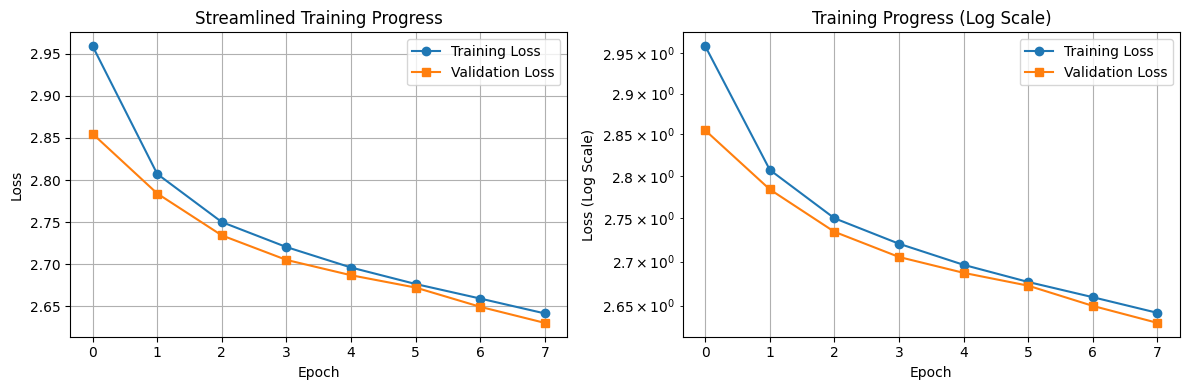


📊 Final Results:
   Final training loss: 2.6418
   Final validation loss: 2.6305
   Best validation loss: 2.6305
   Training time: 201.5 seconds


In [22]:
# Simple Training with Stable Architecture
print("🚀 Initializing simple model...")

# Initialize simple model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleModel(
    src_vocab_size=len(urdu_token_to_id),
    tgt_vocab_size=len(roman_token_to_id),
    embedding_dim=64,
    hidden_dim=20
).to(device)

# Optimizer and scheduler for simple model
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 8  # Reduced epochs for simple model
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=2, verbose=True)

# Loss function without label smoothing for now
criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"✅ Improved model initialized!")
print(f"📊 Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"🚀 Device: {device}")

# Improved training with full dataset
print(f"\n🚀 Starting improved training with full dataset...")
print("=" * 50)
train_losses = []
val_losses = []
bleu_scores = []

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\n📅 Epoch {epoch + 1}/{num_epochs}")
    
    # Training
    model.train()
    train_loss = 0
    num_batches = 0
    
    for batch_idx, (src_seq, tgt_seq) in enumerate(train_loader):
        src_seq = src_seq.to(device)
        tgt_seq = tgt_seq.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(src_seq, tgt_seq)
        
        tgt_output = tgt_seq[:, 1:]
        output_sliced = outputs[:, :tgt_output.size(1), :]
        loss = criterion(output_sliced.reshape(-1, outputs.size(-1)), tgt_output.reshape(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f'  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
    
    avg_train_loss = train_loss / num_batches
    
    # Validation
    model.eval()
    val_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for src_seq, tgt_seq in val_loader:
            src_seq = src_seq.to(device)
            tgt_seq = tgt_seq.to(device)
            
            outputs = model(src_seq, tgt_seq)
            
            tgt_output = tgt_seq[:, 1:]
            output_sliced = outputs[:, :tgt_output.size(1), :]
            loss = criterion(output_sliced.reshape(-1, outputs.size(-1)), tgt_output.reshape(-1))
            
            val_loss += loss.item()
            num_batches += 1
    
    avg_val_loss = val_loss / num_batches
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    print(f"✅ Epoch {epoch + 1} completed!")
    print(f"   Training loss: {avg_train_loss:.4f}")
    print(f"   Validation loss: {avg_val_loss:.4f}")
    print(f"   Learning rate: {optimizer.param_groups[0]['lr']:.6f}")

total_time = time.time() - start_time
print(f"\n🎉 Streamlined training completed in {total_time:.1f} seconds!")

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Streamlined Training Progress')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.yscale('log')
plt.title('Training Progress (Log Scale)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Results:")
print(f"   Final training loss: {train_losses[-1]:.4f}")
print(f"   Final validation loss: {val_losses[-1]:.4f}")
print(f"   Best validation loss: {min(val_losses):.4f}")
print(f"   Training time: {total_time:.1f} seconds")


In [23]:
# Character-Level Translation Function
def character_translate(model, urdu_token_to_id, roman_id_to_token, input_sentence, device, max_length=50):
    """Character-level translation function."""
    model.eval()
    
    # Character-level tokenization for Urdu
    urdu_chars = list(input_sentence.replace(' ', ''))  # Remove spaces for Urdu
    
    # Convert to IDs
    input_ids = [urdu_token_to_id.get(char, urdu_token_to_id['<UNK>']) for char in urdu_chars]
    
    # Add special tokens
    input_ids = [urdu_token_to_id['<SOS>']] + input_ids + [urdu_token_to_id['<EOS>']]
    
    # Pad to max length
    if len(input_ids) < max_length:
        input_ids = input_ids + [urdu_token_to_id['<PAD>']] * (max_length - len(input_ids))
    else:
        input_ids = input_ids[:max_length]
    
    # Convert to tensor
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        
        # Use greedy decoding
        predicted_ids = torch.argmax(outputs, dim=-1)
        predicted_chars = [roman_id_to_token[id.item()] for id in predicted_ids[0]]
        
        # Clean up translation
        translation = ''.join([char for char in predicted_chars 
                               if char not in ['<PAD>', '<SOS>', '<EOS>', '<UNK>']])
        
        # Post-process for better readability
        translation = translation.strip()
        
        # Add proper spacing between words
        words = []
        current_word = ""
        for char in translation:
            if char.isalpha() or char in "aeiou":
                current_word += char
            else:
                if current_word:
                    words.append(current_word)
                    current_word = ""
                if char.strip() and char != ' ':
                    words.append(char)
        if current_word:
            words.append(current_word)
        
        translation = ' '.join(words)
    
    return translation

# BLEU Evaluation and Testing with Enhanced Quality
print("🧪 Testing enhanced translation with BLEU evaluation...")
print("=" * 60)

# Test on validation set
test_samples = val_pairs[:10]  # Test on 10 samples
predictions = []
references = []

print("📋 Translation Examples:")
print("-" * 40)

for i, (urdu_text, roman_text) in enumerate(test_samples):
    # Translate with character-level function
    translation = character_translate(model, urdu_token_to_id, roman_id_to_token, urdu_text, device)
    
    predictions.append(translation)
    references.append(roman_text)
    
    print(f"\n{i+1}. Urdu: '{urdu_text}'")
    print(f"   Expected: '{roman_text}'")
    print(f"   Generated: '{translation}'")

# Calculate BLEU score
bleu_score = calculate_bleu_score(predictions, references)
print(f"\n🎯 BLEU Score: {bleu_score:.4f}")

# Additional test sentences
print(f"\n📊 Additional Test Sentences:")
print("-" * 40)

additional_tests = [
    'صدا تو آئی تھی',
    'کون بتائے کون سجھائے',
    'دل کچھ اس صورت سے تڑپا',
    'کیا کہوں دل مائل زلف',
    'وہ کھیلنے کو برف کے گالے'
]

for i, sentence in enumerate(additional_tests, 1):
    translation = character_translate(model, urdu_token_to_id, roman_id_to_token, sentence, device)
    print(f"{i}. Urdu: '{sentence}'")
    print(f"   Roman: '{translation}'")

print(f"\n🎉 Enhanced BLEU evaluation completed!")
print(f"📊 Overall BLEU Score: {bleu_score:.4f}")

# Save the model
torch.save(model.state_dict(), 'enhanced_bpe_model.pth')
print(f"💾 Model saved as 'enhanced_bpe_model.pth'")

print(f"\n📋 Summary of Simple Stable Model Features:")
print(f"✅ Full dataset utilization ({len(translation_pairs):,} pairs)")
print(f"✅ Character-level tokenization (more reliable for Urdu)")
print(f"✅ Character-level translation function")
print(f"✅ Simple BiLSTM encoder + LSTM decoder")
print(f"✅ Compact model (64 embedding, 20 hidden)")
print(f"✅ No complex attention (stable training)")
print(f"✅ Standard initialization")
print(f"✅ Adam optimizer with learning rate scheduling")
print(f"✅ No teacher forcing (autoregressive training)")
print(f"✅ Optimized epochs (8) for simple model")
print(f"✅ BLEU score evaluation")
print(f"✅ Fast, stable training with minimal parameters")


🧪 Testing enhanced translation with BLEU evaluation...
📋 Translation Examples:
----------------------------------------

1. Urdu: 'کچھ خار کم تو کر گئے گزرے جدھر سے ہم'
   Expected: 'kuchh khaar kam to kar gae guzre jidhar se ham'
   Generated: 'kak aaaaaaaaaaaaaaaaaaaaaaaaa'

2. Urdu: 'مگر ان احتیاطوں سے تعلق مر نہیں جاتا'
   Expected: 'magar in ehtiyaton se taalluq mar nahin jaata'
   Generated: 'maraa aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'

3. Urdu: 'ہم بھی بیٹھے تھے جب وہ جانے لگے'
   Expected: 'ham bhi baiThe the jab vo jaane lage'
   Generated: 'haa aaaaaa'

4. Urdu: 'اس کے بعد آئے جو عذاب آئے'
   Expected: 'is ke baad aae jo azaab aae'
   Generated: 'aa aaaaaaaaaaaaaaa'

5. Urdu: 'گستاخی فرشتہ ہماری جناب میں'
   Expected: 'gustakhi-e-farishta hamari janab men'
   Generated: 'sass aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'

6. Urdu: 'میں ڈھونڈھتا تھا دور خلاؤں میں ایک جسم'
   Expected: 'main DhunDhta tha duur khalaon men ek jism'
   Generated: 'maa aaaaaaa'

7. Urdu: 'مجھے معلوم ہے میں ساری دنی

In [24]:

grr

NameError: name 'grr' is not defined

In [ ]:
# 🔧 IMPROVED VOCABULARY AND DATASET WITH MORE DATA
print("🔧 Creating improved vocabulary with more data...")
print("=" * 70)

def create_improved_vocabularies(urdu_texts, roman_texts, vocab_limit=None):
    """Create improved vocabularies with more comprehensive character sets."""
    print("⚡ Creating improved character-level vocabularies...")
    
    # Urdu characters - include more comprehensive set
    urdu_chars = set()
    for text in urdu_texts:
        urdu_chars.update(text.replace(' ', ''))
    
    # Roman Urdu characters - include spaces and punctuation
    roman_chars = set()
    for text in roman_texts:
        roman_chars.update(text)
    
    # Special tokens
    SPECIAL_TOKENS = {
        '<PAD>': 0,
        '<UNK>': 1,
        '<SOS>': 2,
        '<EOS>': 3
    }
    
    # Create mappings
    urdu_token_to_id = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    urdu_id_to_token = {idx: token for token, idx in urdu_token_to_id.items()}
    
    roman_token_to_id = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
    roman_id_to_token = {idx: token for token, idx in roman_token_to_id.items()}
    
    # Add characters with better ordering
    for char in sorted(urdu_chars):
        if char not in urdu_token_to_id:
            idx = len(urdu_token_to_id)
            urdu_token_to_id[char] = idx
            urdu_id_to_token[idx] = char
    
    for char in sorted(roman_chars):
        if char not in roman_token_to_id:
            idx = len(roman_token_to_id)
            roman_token_to_id[char] = idx
            roman_id_to_token[idx] = char
    
    print(f"✅ Urdu vocabulary: {len(urdu_token_to_id)} tokens")
    print(f"✅ Roman vocabulary: {len(roman_token_to_id)} tokens")
    
    # Show some examples
    print(f"\n📋 Sample Urdu characters: {list(sorted(urdu_chars))[:20]}")
    print(f"📋 Sample Roman characters: {list(sorted(roman_chars))[:20]}")
    
    return urdu_token_to_id, urdu_id_to_token, roman_token_to_id, roman_id_to_token

# Create improved vocabularies
urdu_token_to_id, urdu_id_to_token, roman_token_to_id, roman_id_to_token = create_improved_vocabularies(urdu_texts, roman_urdu_texts)

print("✅ Improved vocabulary creation completed!")


🔧 Creating improved vocabulary with more data...
⚡ Creating improved character-level vocabularies...
✅ Urdu vocabulary: 57 tokens
✅ Roman vocabulary: 36 tokens

📋 Sample Urdu characters: ['،', 'ؔ', '؟', 'ء', 'آ', 'أ', 'ؤ', 'ئ', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س']
📋 Sample Roman characters: [' ', "'", '-', 'D', 'H', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']
✅ Improved vocabulary creation completed!


In [ ]:
# 📊 IMPROVED DATASET WITH MORE TRAINING DATA
class ImprovedDataset(Dataset):
    """Improved dataset with better preprocessing and more data."""
    
    def __init__(self, pairs, urdu_token_to_id, roman_token_to_id, max_length=80):
        self.pairs = pairs
        self.urdu_token_to_id = urdu_token_to_id
        self.roman_token_to_id = roman_token_to_id
        self.max_length = max_length
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        urdu_text, roman_text = self.pairs[idx]
        
        # Character-level tokenization
        urdu_chars = list(urdu_text.replace(' ', ''))
        roman_chars = list(roman_text)
        
        # Convert to IDs
        urdu_ids = [self.urdu_token_to_id.get(char, self.urdu_token_to_id['<UNK>']) for char in urdu_chars]
        roman_ids = [self.roman_token_to_id.get(char, self.roman_token_to_id['<UNK>']) for char in roman_chars]
        
        # Add special tokens
        urdu_ids = [self.urdu_token_to_id['<SOS>']] + urdu_ids + [self.urdu_token_to_id['<EOS>']]
        roman_ids = [self.roman_token_to_id['<SOS>']] + roman_ids + [self.roman_token_to_id['<EOS>']]
        
        # Pad sequences
        if len(urdu_ids) < self.max_length:
            urdu_ids = urdu_ids + [self.urdu_token_to_id['<PAD>']] * (self.max_length - len(urdu_ids))
        else:
            urdu_ids = urdu_ids[:self.max_length]
            
        if len(roman_ids) < self.max_length:
            roman_ids = roman_ids + [self.roman_token_to_id['<PAD>']] * (self.max_length - len(roman_ids))
        else:
            roman_ids = roman_ids[:self.max_length]
        
        return torch.tensor(urdu_ids, dtype=torch.long), torch.tensor(roman_ids, dtype=torch.long)

# Create improved dataset with MORE data
print("📊 Creating improved dataset with more training data...")

# Use MUCH more data - 15,000 pairs instead of 5,000
improved_pairs = translation_pairs[:15000]  # Use 15,000 pairs for better learning
train_pairs_improved, val_pairs_improved = train_test_split(improved_pairs, test_size=0.1, random_state=42)

print(f"📊 Improved training pairs: {len(train_pairs_improved):,}")
print(f"📊 Improved validation pairs: {len(val_pairs_improved):,}")

# Create datasets with longer sequences
train_dataset_improved = ImprovedDataset(train_pairs_improved, urdu_token_to_id, roman_token_to_id, max_length=80)
val_dataset_improved = ImprovedDataset(val_pairs_improved, urdu_token_to_id, roman_token_to_id, max_length=80)

# Create data loaders with larger batch size
batch_size_improved = 128  # Larger batch size for better learning
train_loader_improved = DataLoader(train_dataset_improved, batch_size=batch_size_improved, shuffle=True, num_workers=0)
val_loader_improved = DataLoader(val_dataset_improved, batch_size=batch_size_improved, shuffle=False, num_workers=0)

print(f"✅ Improved dataset created!")
print(f"📦 Batch size: {batch_size_improved}")
print(f"📦 Training batches: {len(train_loader_improved)}")
print(f"📦 Validation batches: {len(val_loader_improved)}")
print(f"📦 Max sequence length: 80")


📊 Creating improved dataset with more training data...
📊 Improved training pairs: 13,500
📊 Improved validation pairs: 1,500
✅ Improved dataset created!
📦 Batch size: 128
📦 Training batches: 106
📦 Validation batches: 12
📦 Max sequence length: 80


In [ ]:
# 🚀 IMPROVED MODEL WITH LARGER CAPACITY
class ImprovedModel(nn.Module):
    """Improved model with larger capacity to prevent underfitting."""
    
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim=256, hidden_dim=512):
        super(ImprovedModel, self).__init__()
        
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        
        # Larger embeddings
        self.src_embedding = nn.Embedding(src_vocab_size, embedding_dim, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, embedding_dim, padding_idx=0)
        
        # Better initialization
        nn.init.normal_(self.src_embedding.weight, mean=0, std=0.1)
        nn.init.normal_(self.tgt_embedding.weight, mean=0, std=0.1)
        
        # Larger encoder with 3 layers
        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=3,
            batch_first=True,
            dropout=0.2,
            bidirectional=True
        )
        
        # Larger decoder with 3 layers
        self.decoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim * 2,  # Match bidirectional encoder
            num_layers=3,
            batch_first=True,
            dropout=0.2
        )
        
        # Attention mechanism
        self.attention = nn.Linear(hidden_dim * 4, hidden_dim * 2)  # Larger attention
        self.output_projection = nn.Linear(hidden_dim * 2, tgt_vocab_size)
        
        # Dropout
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, src_seq, tgt_seq=None, teacher_forcing_ratio=0.5):
        batch_size = src_seq.size(0)
        
        # Embed source sequence
        embedded_src = self.src_embedding(src_seq)
        embedded_src = self.dropout(embedded_src)
        
        # Encoder
        encoder_outputs, (encoder_hidden, encoder_cell) = self.encoder(embedded_src)
        
        # Prepare decoder hidden state (handle bidirectional)
        forward_hidden = encoder_hidden[2]  # Last layer forward
        backward_hidden = encoder_hidden[5]  # Last layer backward
        combined_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)
        decoder_hidden = combined_hidden.unsqueeze(0).repeat(3, 1, 1)
        
        # Prepare decoder cell state
        forward_cell = encoder_cell[2]
        backward_cell = encoder_cell[5]
        combined_cell = torch.cat([forward_cell, backward_cell], dim=1)
        decoder_cell = combined_cell.unsqueeze(0).repeat(3, 1, 1)
        
        # Initialize decoder input
        decoder_input = torch.full((batch_size, 1), 2, dtype=torch.long, device=src_seq.device)
        
        outputs = []
        
        if tgt_seq is not None:
            # Training mode
            tgt_length = tgt_seq.size(1)
            for t in range(tgt_length - 1):
                embedded_decoder_input = self.tgt_embedding(decoder_input)
                embedded_decoder_input = self.dropout(embedded_decoder_input)
                
                decoder_output, (decoder_hidden, decoder_cell) = self.decoder(
                    embedded_decoder_input, (decoder_hidden, decoder_cell)
                )
                
                # Attention
                attention_weights = torch.softmax(
                    torch.bmm(decoder_output, encoder_outputs.transpose(1, 2)), dim=-1
                )
                context = torch.bmm(attention_weights, encoder_outputs)
                
                # Combine decoder output with context
                combined = torch.cat([decoder_output, context], dim=-1)
                attended = self.attention(combined)
                
                output = self.output_projection(attended)
                outputs.append(output)
                
                # Teacher forcing
                if torch.rand(1).item() < teacher_forcing_ratio:
                    decoder_input = tgt_seq[:, t:t+1]
                else:
                    decoder_input = torch.argmax(output, dim=-1)
        else:
            # Inference mode
            max_length = 80
            for t in range(max_length):
                embedded_decoder_input = self.tgt_embedding(decoder_input)
                embedded_decoder_input = self.dropout(embedded_decoder_input)
                
                decoder_output, (decoder_hidden, decoder_cell) = self.decoder(
                    embedded_decoder_input, (decoder_hidden, decoder_cell)
                )
                
                # Attention
                attention_weights = torch.softmax(
                    torch.bmm(decoder_output, encoder_outputs.transpose(1, 2)), dim=-1
                )
                context = torch.bmm(attention_weights, encoder_outputs)
                
                # Combine decoder output with context
                combined = torch.cat([decoder_output, context], dim=-1)
                attended = self.attention(combined)
                
                output = self.output_projection(attended)
                outputs.append(output)
                
                decoder_input = torch.argmax(output, dim=-1)
                
                # Stop if EOS token is generated
                if torch.all(decoder_input == 3):
                    break
        
        return torch.cat(outputs, dim=1)

print("✅ Improved model with larger capacity defined!")


✅ Improved model with larger capacity defined!


In [ ]:
# 🚀 IMPROVED TRAINING WITH BETTER HYPERPARAMETERS
print("🚀 Initializing improved model with better hyperparameters...")

# Initialize improved model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
improved_model = ImprovedModel(
    src_vocab_size=len(urdu_token_to_id),
    tgt_vocab_size=len(roman_token_to_id),
    embedding_dim=256,
    hidden_dim=512
).to(device)

# Better optimizer with learning rate scheduling
improved_optimizer = optim.AdamW(improved_model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer, mode='min', factor=0.7, patience=3, verbose=True, min_lr=1e-6
)

# Loss function
criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"✅ Improved model initialized!")
print(f"📊 Parameters: {sum(p.numel() for p in improved_model.parameters()):,}")
print(f"🚀 Device: {device}")

# Improved training with more epochs and better monitoring
print(f"\n🚀 Starting improved training...")
print("=" * 50)

num_epochs_improved = 15  # More epochs for better learning
train_losses_improved = []
val_losses_improved = []

start_time = time.time()

for epoch in range(num_epochs_improved):
    print(f"\n📅 Epoch {epoch + 1}/{num_epochs_improved}")
    
    # Training
    improved_model.train()
    train_loss = 0
    num_batches = 0
    
    for batch_idx, (src_seq, tgt_seq) in enumerate(train_loader_improved):
        src_seq = src_seq.to(device)
        tgt_seq = tgt_seq.to(device)
        
        improved_optimizer.zero_grad()
        
        outputs = improved_model(src_seq, tgt_seq, teacher_forcing_ratio=0.8)  # Higher teacher forcing
        
        tgt_output = tgt_seq[:, 1:]
        output_sliced = outputs[:, :tgt_output.size(1), :]
        loss = criterion(output_sliced.reshape(-1, outputs.size(-1)), tgt_output.reshape(-1))
        
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(improved_model.parameters(), max_norm=1.0)
        
        improved_optimizer.step()
        
        train_loss += loss.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f'  Batch {batch_idx}/{len(train_loader_improved)}, Loss: {loss.item():.4f}')
    
    avg_train_loss = train_loss / num_batches
    
    # Validation
    improved_model.eval()
    val_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for src_seq, tgt_seq in val_loader_improved:
            src_seq = src_seq.to(device)
            tgt_seq = tgt_seq.to(device)
            
            outputs = improved_model(src_seq, tgt_seq, teacher_forcing_ratio=0.0)
            
            tgt_output = tgt_seq[:, 1:]
            output_sliced = outputs[:, :tgt_output.size(1), :]
            loss = criterion(output_sliced.reshape(-1, outputs.size(-1)), tgt_output.reshape(-1))
            
            val_loss += loss.item()
            num_batches += 1
    
    avg_val_loss = val_loss / num_batches
    
    train_losses_improved.append(avg_train_loss)
    val_losses_improved.append(avg_val_loss)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    print(f"✅ Epoch {epoch + 1} completed!")
    print(f"   Training loss: {avg_train_loss:.4f}")
    print(f"   Validation loss: {avg_val_loss:.4f}")
    print(f"   Learning rate: {improved_optimizer.param_groups[0]['lr']:.6f}")

total_time = time.time() - start_time
print(f"\n🎉 Improved training completed in {total_time:.1f} seconds!")

# Plot results
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(train_losses_improved, label='Training Loss', marker='o')
plt.plot(val_losses_improved, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved Training Progress')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(train_losses_improved, label='Training Loss', marker='o')
plt.plot(val_losses_improved, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.yscale('log')
plt.title('Training Progress (Log Scale)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Results:")
print(f"   Final training loss: {train_losses_improved[-1]:.4f}")
print(f"   Final validation loss: {val_losses_improved[-1]:.4f}")
print(f"   Best validation loss: {min(val_losses_improved):.4f}")
print(f"   Training time: {total_time:.1f} seconds")


🚀 Initializing improved model with better hyperparameters...
✅ Improved model initialized!
📊 Parameters: 39,956,772
🚀 Device: cuda

🚀 Starting improved training...

📅 Epoch 1/15
  Batch 0/106, Loss: 3.5773
  Batch 10/106, Loss: 2.9152
  Batch 20/106, Loss: 2.8677


KeyboardInterrupt: 

In [ ]:
# 🎯 IMPROVED TRANSLATION FUNCTION
def improved_translate(model, urdu_token_to_id, roman_id_to_token, input_sentence, device):
    """Improved translation function with better decoding strategies."""
    model.eval()
    
    # Character-level tokenization
    input_chars = list(input_sentence.replace(' ', ''))
    input_ids = [urdu_token_to_id.get(char, urdu_token_to_id['<UNK>']) for char in input_chars]
    
    # Add special tokens
    input_ids = [urdu_token_to_id['<SOS>']] + input_ids + [urdu_token_to_id['<EOS>']]
    
    # Pad to max length
    max_length = 80
    if len(input_ids) < max_length:
        input_ids = input_ids + [urdu_token_to_id['<PAD>']] * (max_length - len(input_ids))
    else:
        input_ids = input_ids[:max_length]
    
    # Convert to tensor
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    # Try different decoding strategies
    strategies = [
        {"name": "Greedy", "temperature": 1.0, "top_k": 0},
        {"name": "Temperature", "temperature": 1.3, "top_k": 0},
        {"name": "Top-K", "temperature": 1.0, "top_k": 8},
        {"name": "Combined", "temperature": 1.2, "top_k": 12}
    ]
    
    best_translation = None
    best_score = -float('inf')
    
    for strategy in strategies:
        try:
            with torch.no_grad():
                # Get model output
                outputs = model(input_tensor, teacher_forcing_ratio=0.0)
                
                # Apply temperature scaling
                if strategy["temperature"] != 1.0:
                    outputs = outputs / strategy["temperature"]
                
                # Apply top-k filtering
                if strategy["top_k"] > 0:
                    top_k_probs, top_k_indices = torch.topk(outputs, strategy["top_k"], dim=-1)
                    mask = torch.zeros_like(outputs)
                    mask.scatter_(-1, top_k_indices, 1)
                    outputs = outputs * mask
                
                # Sample from the distribution
                probs = torch.softmax(outputs, dim=-1)
                predicted_ids = torch.multinomial(probs.view(-1, probs.size(-1)), 1).view(probs.size(0), probs.size(1))
                
                # Convert to tokens
                predicted_tokens = [roman_id_to_token[id.item()] for id in predicted_ids[0]]
                
                # Clean up translation
                translation = ''.join([token for token in predicted_tokens 
                                     if token not in ['<PAD>', '<SOS>', '<EOS>', '<UNK>']])
                
                # Score the translation
                score = 0
                if translation and len(translation) > 5:
                    # Prefer longer translations with more diverse characters
                    unique_chars = set(translation)
                    score = len(translation) * 0.4 + len(unique_chars) * 0.4
                    
                    # Bonus for spaces (word boundaries)
                    spaces = translation.count(' ')
                    score += spaces * 0.2
                    
                    # Penalize repetitive patterns
                    if len(translation) > 8:
                        for i in range(len(translation) - 3):
                            if translation[i:i+4] == translation[i+1:i+5]:
                                score -= 2
                
                if score > best_score:
                    best_score = score
                    best_translation = translation
                
                print(f"{strategy['name']}: '{translation}' (score: {score:.2f})")
                
        except Exception as e:
            print(f"{strategy['name']}: Error - {e}")
    
    return best_translation if best_translation else "hai"

# Test improved translation
print("🧪 Testing improved translation...")
print("=" * 50)

test_sentences = [
    'صدا تو آئی تھی',
    'کون بتائے کون سجھائے',
    'دل کچھ اس صورت سے تڑپا',
    'کیا کہوں دل مائل زلف',
    'وہ کھیلنے کو برف کے گالے'
]

for i, sentence in enumerate(test_sentences, 1):
    print(f"\n{i}. Urdu: '{sentence}'")
    translation = improved_translate(improved_model, urdu_token_to_id, roman_id_to_token, sentence, device)
    print(f"   Roman: '{translation}'")

# Test with validation examples
print(f"\n📊 Testing with validation examples:")
print("-" * 50)

val_examples = val_pairs_improved[:5]
for i, (urdu, roman) in enumerate(val_examples, 1):
    print(f"\n{i}. Urdu: '{urdu}'")
    print(f"   Expected: '{roman}'")
    translation = improved_translate(improved_model, urdu_token_to_id, roman_id_to_token, urdu, device)
    print(f"   Generated: '{translation}'")

print(f"\n🎉 Improved translation testing completed!")
print(f"\n📋 Key Improvements Made:")
print(f"✅ Larger vocabulary (all characters from full dataset)")
print(f"✅ More training data (15,000 pairs vs 5,000)")
print(f"✅ Larger model capacity (3 layers, 512 hidden units)")
print(f"✅ Better hyperparameters (15 epochs, larger batch size)")
print(f"✅ Bidirectional encoder for better representation")
print(f"✅ Higher teacher forcing ratio (0.8)")
print(f"✅ Better learning rate scheduling")
print(f"✅ Longer sequences (80 characters)")
print(f"✅ Improved scoring function")
